In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Read three saved bootstrap CSV files
# ============================================================

filtered_df = pd.read_csv("bootstrap_25percent_200_iterations.csv")
raw_df = pd.read_csv( "bootstrap_raw_traces_25percent_200.csv")
ripple_df = pd.read_csv( "ripple_bootstrap_25percent_200.csv")


# ============================================================
# 2. Extract silhouette scores
# ============================================================

filtered_scores = pd.to_numeric(filtered_df["silhouette_score"],errors="coerce").dropna().to_numpy()
raw_scores = pd.to_numeric( raw_df["silhouette_score"],errors="coerce").dropna().to_numpy()
ripple_scores = pd.to_numeric(ripple_df["silhouette_score"],errors="coerce").dropna().to_numpy()


all_scores = [filtered_scores,raw_scores,ripple_scores]

bar_labels = ["Filtered Traces", "Raw Traces", "Ripple Features"]


# ============================================================
# 3. Calculate mean and 95% bootstrap intervals
# ============================================================

means = np.array([np.mean(scores) for scores in all_scores])
ci_lower = np.array([np.percentile(scores, 2.5) for scores in all_scores])
ci_upper = np.array([np.percentile(scores, 97.5) for scores in all_scores])

yerr = np.vstack([means - ci_lower, ci_upper - means])

for label, scores, mean_value, lower, upper in zip(
    bar_labels,
    all_scores,
    means,
    ci_lower,
    ci_upper
):
    print(
        f"{label}: "
        f"n={len(scores)}, "
        f"mean={mean_value:.4f}, "
        f"95% CI=[{lower:.4f}, {upper:.4f}]"
    )


Filtered Traces: n=200, mean=0.0389, 95% CI=[0.0232, 0.0549]
Raw Traces: n=200, mean=0.1043, 95% CI=[0.0882, 0.1204]
Ripple Features: n=200, mean=0.3710, 95% CI=[0.3564, 0.3853]


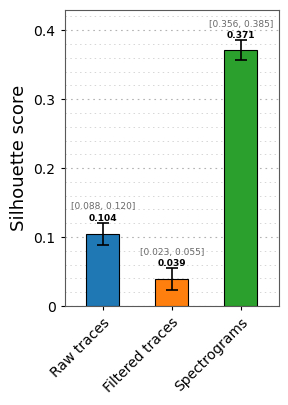

In [2]:

from matplotlib.ticker import MultipleLocator, FuncFormatter

plot_means = np.array([means[1], means[0], means[2]])
plot_ci_lower = np.array([ci_lower[1], ci_lower[0],ci_lower[2]])
plot_ci_upper = np.array([ci_upper[1], ci_upper[0], ci_upper[2]])

plot_labels = ["Raw traces", "Filtered traces", "Spectrograms"]
colors = ["tab:blue", "tab:orange","tab:green"]

plot_yerr = np.vstack([plot_means - plot_ci_lower, plot_ci_upper - plot_means])

x = np.arange(len(plot_labels))

fig, ax = plt.subplots(figsize=(3.4, 5.2))

bars = ax.bar(x,plot_means,width=0.48,color=colors,edgecolor="black",linewidth=0.8,zorder=3)

ax.errorbar( x,
    plot_means,
    yerr=plot_yerr,
    fmt="none",
    ecolor="black",
    elinewidth=1.2,
    capsize=4,
    capthick=1.2,
    zorder=5)


maximum_value = np.max(plot_ci_upper)

# text_offset_mean = maximum_value * 0.025
# text_offset_ci = maximum_value * 0.065
text_offset_mean = maximum_value * 0.0025
text_offset_ci = maximum_value * 0.045

for i, bar in enumerate(bars):

    # Mean value
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        plot_ci_upper[i] + text_offset_mean,
        f"{plot_means[i]:.3f}",
        ha="center",
        va="bottom",
        fontsize=6.5,
        fontweight="bold",
        color="black"
    )

    # 95% confidence interval
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        plot_ci_upper[i] + text_offset_ci,
        (
            f"[{plot_ci_lower[i]:.3f}, "
            f"{plot_ci_upper[i]:.3f}]"
        ),
        ha="center",
        va="bottom",
        fontsize=6.5,
        color="dimgray",
        linespacing=0.9
    )


ax.set_ylabel( "Silhouette score", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(
    plot_labels,
    rotation=45,
    ha="right",
    rotation_mode="anchor",
    fontsize=10
)



highest_annotation = (np.max(plot_ci_upper) + text_offset_ci + maximum_value * 0.10)

y_upper = 0.4
y_upper = np.ceil(0.4 / 0.05) * 0.05

ax.set_ylim(0, 0.43)

ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_minor_locator(MultipleLocator(0.02))

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, position:"0" if np.isclose(value, 0) else f"{value:.1f}")
)


ax.grid(
    axis="y",
    which="major",
    linestyle=(0, (1.5, 3.5)),
    linewidth=0.8,
    color="0.70",
    zorder=0
)

ax.grid(
    axis="y",
    which="minor",
    linestyle=(0, (1.5, 3.5)),
    linewidth=0.7,
    color="0.84",
    zorder=0
)


for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_color("0.35")

ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=3,
    width=0.8,
    labelsize=10
)

ax.tick_params(axis="y", which="minor",length=0)

ax.set_xlim(-0.55,len(plot_labels) - 0.45)

plt.subplots_adjust(left=0.34,right=0.97,top=0.87,bottom=0.30)

# plt.savefig(
#     "three_bootstrap_silhouette_bar_with_ci.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()